In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

df = pd.read_csv("../data/processed/retail_store_inventory_clean.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (73100, 15)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Inventory Level,73100.00,274.47,129.95,50.00,162.00,273.00,387.00,500.00
Units Sold,73100.00,136.46,108.92,0.00,49.00,107.00,203.00,499.00
Units Ordered,73100.00,110.00,52.28,20.00,65.00,110.00,155.00,200.00
Demand Forecast,73100.00,141.53,109.21,0.00,53.67,113.02,208.05,518.55
Price,73100.00,55.14,26.02,10.00,32.65,55.05,77.86,100.00
Discount,73100.00,10.01,7.08,0.00,5.00,10.00,15.00,20.00
Holiday/Promotion,73100.00,0.50,0.50,0.00,0.00,0.00,1.00,1.00
Competitor Pricing,73100.00,55.15,26.19,5.03,32.68,55.01,77.82,104.94


In [4]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

In [5]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Extract useful time features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Day_of_Week"] = df["Date"].dt.day_name()
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)

print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("Years:", sorted(df["Year"].unique()))

Date range: 2022-01-01 00:00:00 to 2024-01-01 00:00:00
Years: [2022, 2023, 2024]


In [6]:
# Forecast error
df["Forecast Error"] = df["Units Sold"] - df["Demand Forecast"]

# Absolute forecast error
df["Absolute Forecast Error"] = df["Forecast Error"].abs()

# Percentage error
df["Forecast Error %"] = np.where(
    df["Demand Forecast"] > 0,
    (df["Absolute Forecast Error"] / df["Demand Forecast"]) * 100,
    np.nan
)

df[
    [
        "Units Sold",
        "Demand Forecast",
        "Forecast Error",
        "Absolute Forecast Error",
        "Forecast Error %"
    ]
].head()

,Units Sold,Demand Forecast,Forecast Error,Absolute Forecast Error,Forecast Error %
0,127,135.47,-8.47,8.47,6.25
1,150,144.04,5.96,5.96,4.14
2,65,74.02,-9.02,9.02,12.19
3,61,62.18,-1.18,1.18,1.90
4,14,9.26,4.74,4.74,51.19


In [7]:
# Observations with valid non-negative demand forecasts
valid_forecast = df[df["Demand Forecast"] >= 0].copy()

print("Total observations:", len(df))
print("Valid forecast observations:", len(valid_forecast))
print("Invalid forecast observations:", len(df) - len(valid_forecast))

Total observations: 73100
Valid forecast observations: 73100
Invalid forecast observations: 0


In [8]:
df[
    [
        "Date",
        "Year",
        "Month",
        "Month_Name",
        "Day_of_Week",
        "Week",
        "Forecast Error",
        "Absolute Forecast Error"
    ]
].head(10)

,Date,Year,Month,Month_Name,Day_of_Week,Week,Forecast Error,Absolute Forecast Error
0,2022-01-01,2022,1,January,Saturday,52,-8.47,8.47
1,2022-01-01,2022,1,January,Saturday,52,5.96,5.96
2,2022-01-01,2022,1,January,Saturday,52,-9.02,9.02
3,2022-01-01,2022,1,January,Saturday,52,-1.18,1.18
4,2022-01-01,2022,1,January,Saturday,52,4.74,4.74
5,2022-01-01,2022,1,January,Saturday,52,-11.82,11.82
6,2022-01-01,2022,1,January,Saturday,52,-11.92,11.92
7,2022-01-01,2022,1,January,Saturday,52,-17.73,17.73
8,2022-01-01,2022,1,January,Saturday,52,0.85,0.85
9,2022-01-01,2022,1,January,Saturday,52,3.53,3.53


In [9]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Shape: (73100, 23)

Missing values:
Date                         0
Store ID                     0
Product ID                   0
Category                     0
Region                       0
Inventory Level              0
Units Sold                   0
Units Ordered                0
Demand Forecast              0
Price                        0
Discount                     0
Weather Condition            0
Holiday/Promotion            0
Competitor Pricing           0
Seasonality                  0
Year                         0
Month                        0
Month_Name                   0
Day_of_Week                  0
Week                         0
Forecast Error               0
Absolute Forecast Error      0
Forecast Error %           673
dtype: int64

Data types:
Date                       datetime64[ns]
Store ID                           object
Product ID                         object
Category                           object
Region                             object
Inventory Level

In [10]:
# Verify demand forecast after cleaning

print("Negative Demand Forecast values:",
      (df["Demand Forecast"] < 0).sum())

print("\nDemand Forecast summary:")
print(df["Demand Forecast"].describe())

Negative Demand Forecast values: 0

Demand Forecast summary:
count   73100.00
mean      141.53
std       109.21
min         0.00
25%        53.67
50%       113.02
75%       208.05
max       518.55
Name: Demand Forecast, dtype: float64


In [11]:
# Overall business KPIs

total_sales = df["Units Sold"].sum()
total_orders = df["Units Ordered"].sum()
avg_inventory = df["Inventory Level"].mean()
avg_demand = df["Demand Forecast"].mean()

print(f"Total Units Sold:       {total_sales:,.0f}")
print(f"Total Units Ordered:    {total_orders:,.0f}")
print(f"Average Inventory:      {avg_inventory:.2f}")
print(f"Average Demand Forecast:{avg_demand:.2f}")

Total Units Sold:       9,975,582
Total Units Ordered:    8,041,327
Average Inventory:      274.47
Average Demand Forecast:141.53


In [12]:
# Store-level performance

store_analysis = (
    df.groupby("Store ID")
      .agg(
          total_units_sold=("Units Sold", "sum"),
          total_units_ordered=("Units Ordered", "sum"),
          avg_inventory=("Inventory Level", "mean"),
          avg_demand_forecast=("Demand Forecast", "mean")
      )
      .sort_values("total_units_sold", ascending=False)
)

store_analysis

,total_units_sold,total_units_ordered,avg_inventory,avg_demand_forecast
Store ID,,,,
S003,2022696,1605039,276.87,143.37
S005,2010176,1608902,276.50,142.65
S002,1987715,1605169,273.33,141.01
S004,1979245,1608340,272.30,140.43
S001,1975750,1613877,273.34,140.18


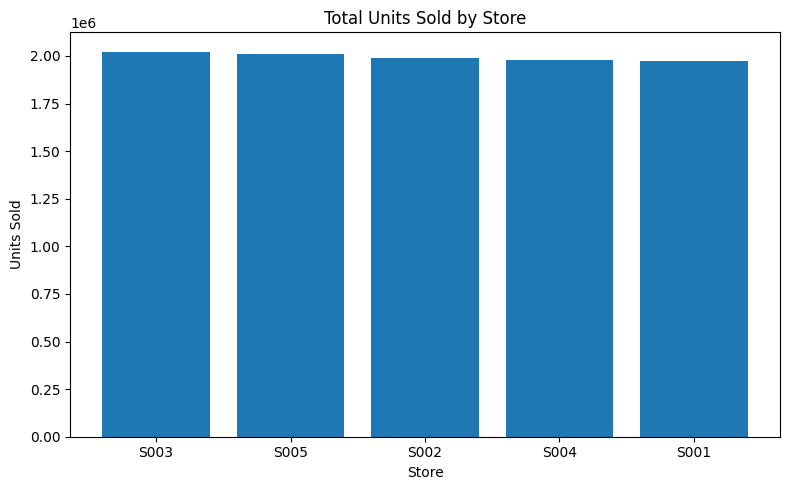

In [13]:
# Visualize total units sold by store

plt.figure(figsize=(8, 5))

plt.bar(
    store_analysis.index,
    store_analysis["total_units_sold"]
)

plt.title("Total Units Sold by Store")
plt.xlabel("Store")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

In [14]:
category_analysis = (
    df.groupby("Category")
      .agg(
          total_units_sold=("Units Sold", "sum"),
          total_units_ordered=("Units Ordered", "sum"),
          avg_inventory=("Inventory Level", "mean"),
          avg_demand_forecast=("Demand Forecast", "mean")
      )
      .sort_values("total_units_sold", ascending=False)
)

category_analysis

,total_units_sold,total_units_ordered,avg_inventory,avg_demand_forecast
Category,,,,
Furniture,2025017,1617699,275.82,142.86
Groceries,2000482,1606188,275.76,141.90
Clothing,1999166,1614885,274.60,141.78
Toys,1990485,1610222,273.65,141.05
Electronics,1960432,1592333,272.51,140.04


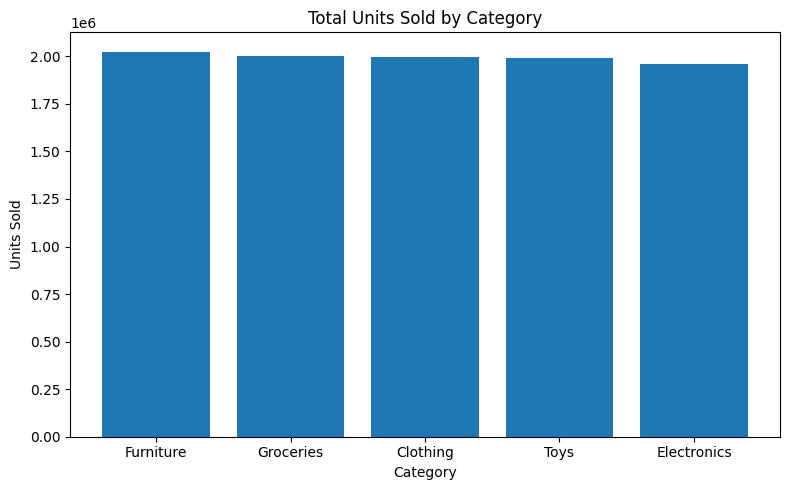

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_analysis.index,
    category_analysis["total_units_sold"]
)

plt.title("Total Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

In [18]:
import numpy as np

df["inventory_risk"] = np.select(
    [
        df["Inventory Level"] < df["Demand Forecast"] * 1.0,
        df["Inventory Level"] <= df["Demand Forecast"] * 1.5,
        df["Inventory Level"] <= df["Demand Forecast"] * 2.0
    ],
    [
        "Understocked",
        "Balanced",
        "High Inventory"
    ],
    default="Excess Inventory"
)

risk_analysis = (
    df["inventory_risk"]
      .value_counts()
      .to_frame("observations")
)

risk_analysis["percentage"] = (
    risk_analysis["observations"] / len(df) * 100
).round(2)

risk_analysis

,observations,percentage
inventory_risk,,
Excess Inventory,35039,47.93
Balanced,23430,32.05
High Inventory,12046,16.48
Understocked,2585,3.54


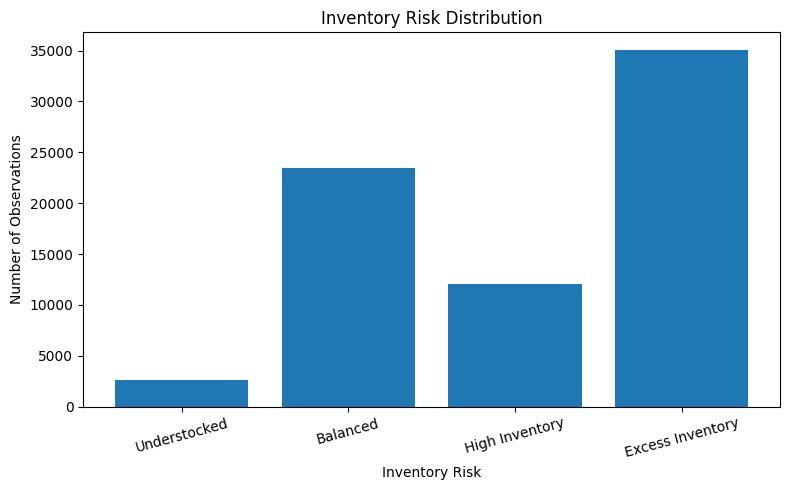

In [19]:
plt.figure(figsize=(8, 5))

risk_order = [
    "Understocked",
    "Balanced",
    "High Inventory",
    "Excess Inventory"
]

risk_counts = (
    risk_analysis
    .reindex(risk_order)["observations"]
)

plt.bar(risk_counts.index, risk_counts.values)

plt.title("Inventory Risk Distribution")
plt.xlabel("Inventory Risk")
plt.ylabel("Number of Observations")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [20]:
# Overstock Analysis
# Overstock Risk = Inventory Level > 1.5 × Demand Forecast

overstock_analysis = (
    df[df["Demand Forecast"] > 0]
    .assign(
        overstock_risk=lambda x:
            x["Inventory Level"] > 1.5 * x["Demand Forecast"]
    )
    .groupby("Product ID")
    .agg(
        observations=("Product ID", "size"),
        overstock_observations=("overstock_risk", "sum"),
        avg_inventory=("Inventory Level", "mean"),
        avg_demand_forecast=("Demand Forecast", "mean"),
        total_units_sold=("Units Sold", "sum")
    )
)

overstock_analysis["overstock_pct"] = (
    100 * overstock_analysis["overstock_observations"]
    / overstock_analysis["observations"]
)

overstock_analysis = (
    overstock_analysis
    .sort_values("overstock_pct", ascending=False)
    .round(2)
)

overstock_analysis.head(20)

,observations,overstock_observations,avg_inventory,avg_demand_forecast,total_units_sold,overstock_pct
Product ID,,,,,,
P0017,3623,2366,279.21,143.30,500424,65.30
P0007,3618,2356,275.70,143.15,499243,65.12
P0002,3622,2355,271.92,139.79,487735,65.02
P0003,3618,2349,275.69,141.60,493136,64.93
P0008,3622,2351,273.48,139.96,488472,64.91
P0020,3620,2346,278.06,145.09,507617,64.81
P0012,3623,2341,273.30,140.83,491577,64.61
P0009,3623,2339,275.91,143.71,501986,64.56
P0014,3625,2322,278.60,145.03,507545,64.06


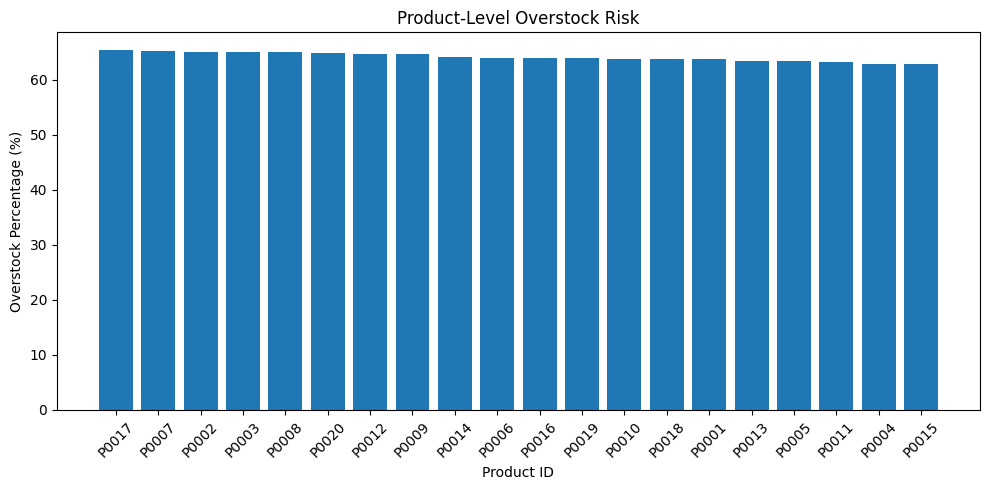

In [21]:
plt.figure(figsize=(10, 5))

top_overstock = overstock_analysis.sort_values(
    "overstock_pct", ascending=False
)

plt.bar(
    top_overstock.index,
    top_overstock["overstock_pct"]
)

plt.title("Product-Level Overstock Risk")
plt.xlabel("Product ID")
plt.ylabel("Overstock Percentage (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [22]:
# Category-Level Overstock Risk

category_overstock = (
    df[df["Demand Forecast"] > 0]
    .assign(
        overstock_risk=lambda x:
            x["Inventory Level"] > 1.5 * x["Demand Forecast"]
    )
    .groupby("Category")
    .agg(
        observations=("Category", "size"),
        overstock_observations=("overstock_risk", "sum"),
        avg_inventory=("Inventory Level", "mean"),
        avg_demand_forecast=("Demand Forecast", "mean"),
        total_units_sold=("Units Sold", "sum")
    )
)

category_overstock["overstock_pct"] = (
    100 * category_overstock["overstock_observations"]
    / category_overstock["observations"]
)

category_overstock = (
    category_overstock
    .sort_values("overstock_pct", ascending=False)
    .round(2)
)

category_overstock

,observations,overstock_observations,avg_inventory,avg_demand_forecast,total_units_sold,overstock_pct
Category,,,,,,
Electronics,14392,9267,273.19,141.29,1960049,64.39
Clothing,14494,9308,275.34,143.07,1998818,64.22
Toys,14503,9305,274.23,142.41,1990075,64.16
Furniture,14570,9302,276.43,144.12,2024604,63.84
Groceries,14468,9230,276.62,143.31,2000076,63.80


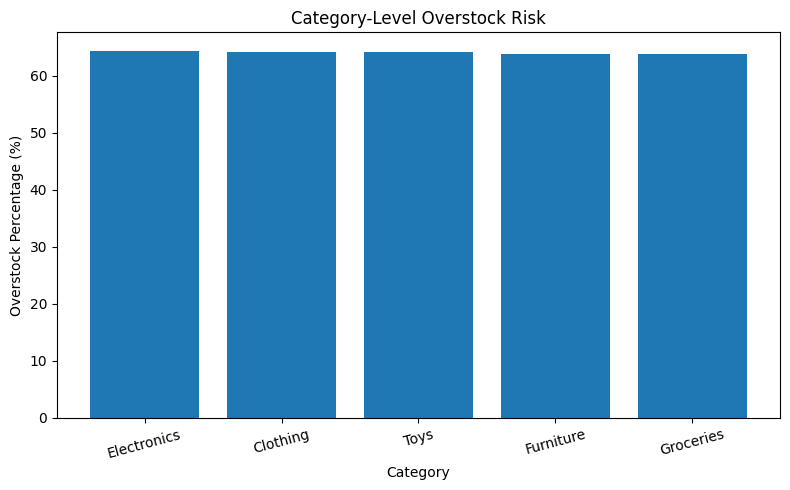

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_overstock.index,
    category_overstock["overstock_pct"]
)

plt.title("Category-Level Overstock Risk")
plt.xlabel("Category")
plt.ylabel("Overstock Percentage (%)")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [24]:
# Inventory Efficiency by Store

store_efficiency = (
    df.groupby("Store ID")
    .agg(
        total_units_sold=("Units Sold", "sum"),
        avg_inventory=("Inventory Level", "mean"),
        avg_demand_forecast=("Demand Forecast", "mean")
    )
)

store_efficiency["inventory_efficiency"] = (
    store_efficiency["total_units_sold"]
    / (store_efficiency["avg_inventory"] * len(df) / df["Store ID"].nunique())
)

store_efficiency = (
    store_efficiency
    .sort_values("inventory_efficiency", ascending=False)
    .round(2)
)

store_efficiency

,total_units_sold,avg_inventory,avg_demand_forecast,inventory_efficiency
Store ID,,,,
S003,2022696,276.87,143.37,0.50
S002,1987715,273.33,141.01,0.50
S005,2010176,276.50,142.65,0.50
S004,1979245,272.30,140.43,0.50
S001,1975750,273.34,140.18,0.49


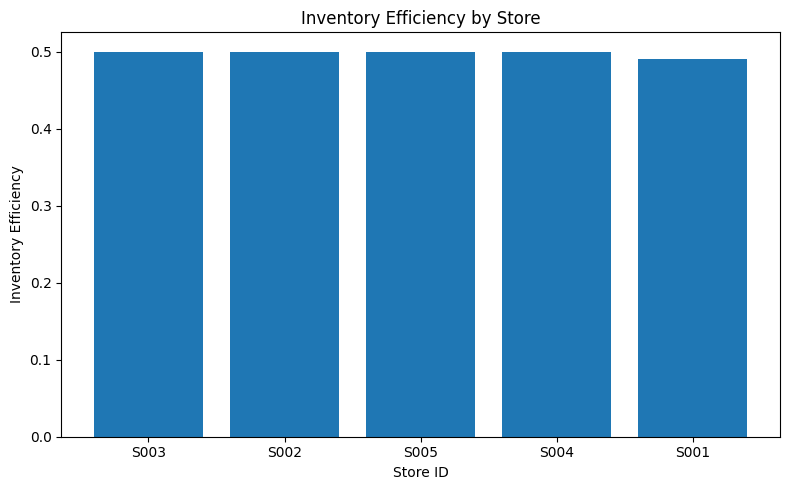

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    store_efficiency.index,
    store_efficiency["inventory_efficiency"]
)

plt.title("Inventory Efficiency by Store")
plt.xlabel("Store ID")
plt.ylabel("Inventory Efficiency")

plt.tight_layout()
plt.show()

In [26]:
# Demand Forecast Accuracy

forecast_eval = df[
    df["Demand Forecast"].notna()
].copy()

forecast_eval["error"] = (
    forecast_eval["Units Sold"]
    - forecast_eval["Demand Forecast"]
)

forecast_eval["absolute_error"] = (
    forecast_eval["error"].abs()
)

forecast_eval["squared_error"] = (
    forecast_eval["error"] ** 2
)

forecast_eval["absolute_percentage_error"] = (
    forecast_eval["absolute_error"]
    / forecast_eval["Units Sold"].replace(0, np.nan)
) * 100

mae = forecast_eval["absolute_error"].mean()
rmse = np.sqrt(forecast_eval["squared_error"].mean())
mape = forecast_eval["absolute_percentage_error"].mean()

pd.DataFrame({
    "MAE": [round(mae, 2)],
    "RMSE": [round(rmse, 2)],
    "MAPE": [round(mape, 2)]
})

,MAE,RMSE,MAPE
0,8.30,10.00,23.29


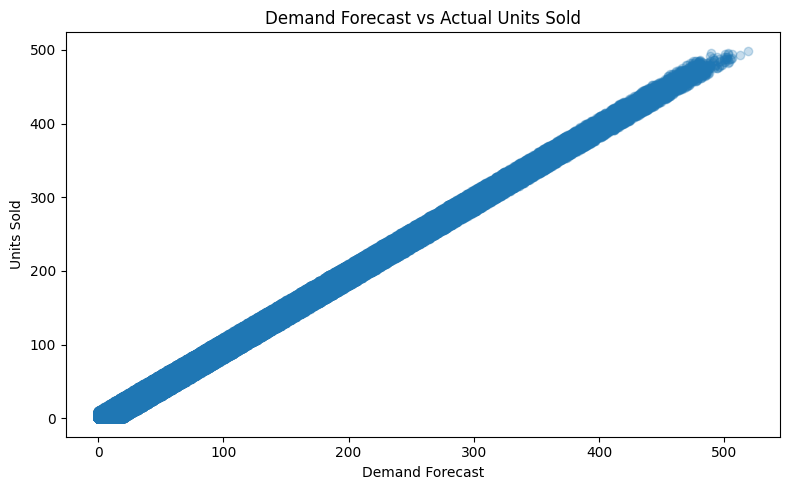

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(
    forecast_eval["Demand Forecast"],
    forecast_eval["Units Sold"],
    alpha=0.25
)

plt.xlabel("Demand Forecast")
plt.ylabel("Units Sold")
plt.title("Demand Forecast vs Actual Units Sold")

plt.tight_layout()
plt.show()

In [28]:
store_forecast_accuracy = (
    forecast_eval
    .groupby("Store ID")
    .agg(
        observations=("Store ID", "size"),
        mae=("absolute_error", "mean"),
        rmse=("squared_error", lambda x: np.sqrt(x.mean())),
        mape=("absolute_percentage_error", "mean")
    )
    .sort_values("mae")
    .round(2)
)

store_forecast_accuracy

,observations,mae,rmse,mape
Store ID,,,,
S001,14620,8.29,9.99,23.40
S003,14620,8.29,9.97,22.31
S002,14620,8.30,10.00,24.10
S004,14620,8.31,10.02,23.74
S005,14620,8.33,10.02,22.91


In [29]:
category_forecast_accuracy = (
    forecast_eval
    .groupby("Category")
    .agg(
        observations=("Category", "size"),
        mae=("absolute_error", "mean"),
        rmse=("squared_error", lambda x: np.sqrt(x.mean())),
        mape=("absolute_percentage_error", "mean")
    )
    .sort_values("mae")
    .round(2)
)

category_forecast_accuracy

,observations,mae,rmse,mape
Category,,,,
Electronics,14521,8.24,9.93,22.22
Groceries,14611,8.29,9.99,24.26
Clothing,14626,8.32,10.01,23.46
Furniture,14699,8.32,10.02,23.00
Toys,14643,8.35,10.04,23.53


In [30]:
risk_forecast_accuracy = (
    forecast_eval
    .assign(
        inventory_risk=lambda x: np.select(
            [
                x["Inventory Level"] < 0.75 * x["Demand Forecast"],
                x["Inventory Level"] <= 1.25 * x["Demand Forecast"],
                x["Inventory Level"] <= 1.50 * x["Demand Forecast"]
            ],
            [
                "Understocked",
                "Balanced",
                "High Inventory"
            ],
            default="Excess Inventory"
        )
    )
    .groupby("inventory_risk")
    .agg(
        observations=("inventory_risk", "size"),
        mae=("absolute_error", "mean"),
        rmse=("squared_error", lambda x: np.sqrt(x.mean())),
        mape=("absolute_percentage_error", "mean")
    )
    .reindex([
        "Understocked",
        "Balanced",
        "High Inventory",
        "Excess Inventory"
    ])
    .round(2)
)

risk_forecast_accuracy

,observations,mae,rmse,mape
inventory_risk,,,,
Understocked,3,19.35,19.36,36.96
Balanced,16419,9.14,10.80,6.20
High Inventory,9593,8.27,9.95,6.47
Excess Inventory,47085,8.02,9.71,32.76


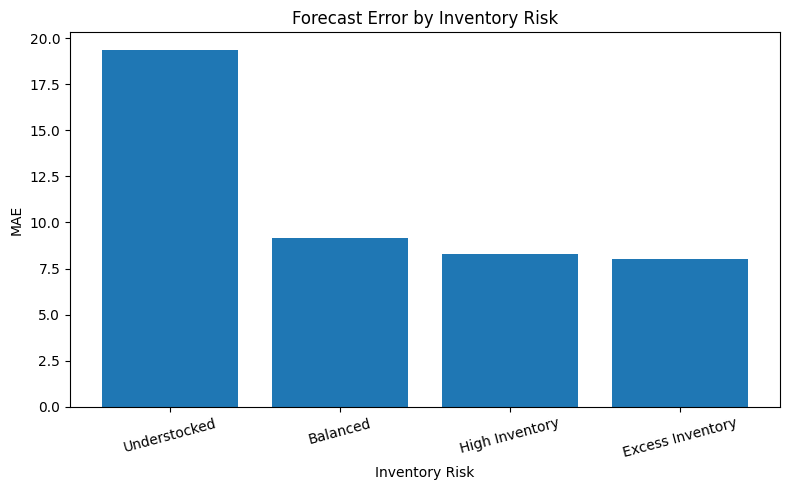

In [31]:
plt.figure(figsize=(8, 5))

plt.bar(
    risk_forecast_accuracy.index,
    risk_forecast_accuracy["mae"]
)

plt.title("Forecast Error by Inventory Risk")
plt.xlabel("Inventory Risk")
plt.ylabel("MAE")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [32]:
discount_analysis = (
    df.groupby("Discount")
    .agg(
        observations=("Discount", "size"),
        avg_units_sold=("Units Sold", "mean"),
        avg_demand_forecast=("Demand Forecast", "mean"),
        avg_inventory=("Inventory Level", "mean"),
        avg_price=("Price", "mean")
    )
    .round(2)
)

discount_analysis

,observations,avg_units_sold,avg_demand_forecast,avg_inventory,avg_price
Discount,,,,,
0,14662,135.69,140.72,272.76,55.07
5,14591,136.57,141.74,275.86,55.23
10,14508,136.77,141.84,273.53,54.95
15,14624,136.66,141.70,274.54,55.19
20,14715,136.64,141.65,275.66,55.23


In [33]:
promotion_analysis = (
    df.groupby("Holiday/Promotion")
    .agg(
        observations=("Holiday/Promotion", "size"),
        avg_units_sold=("Units Sold", "mean"),
        avg_demand_forecast=("Demand Forecast", "mean"),
        avg_inventory=("Inventory Level", "mean"),
        avg_units_ordered=("Units Ordered", "mean")
    )
    .round(2)
)

promotion_analysis

,observations,avg_units_sold,avg_demand_forecast,avg_inventory,avg_units_ordered
Holiday/Promotion,,,,,
0,36747,136.51,141.59,274.03,109.72
1,36353,136.42,141.47,274.92,110.29


In [34]:
seasonality_analysis = (
    df.groupby("Seasonality")
    .agg(
        observations=("Seasonality", "size"),
        avg_units_sold=("Units Sold", "mean"),
        avg_demand_forecast=("Demand Forecast", "mean"),
        avg_inventory=("Inventory Level", "mean"),
        avg_units_ordered=("Units Ordered", "mean")
    )
    .sort_values("avg_units_sold", ascending=False)
    .round(2)
)

seasonality_analysis

,observations,avg_units_sold,avg_demand_forecast,avg_inventory,avg_units_ordered
Seasonality,,,,,
Autumn,18193,137.78,142.84,275.42,109.77
Winter,18285,136.83,141.93,274.65,110.10
Spring,18317,135.83,140.86,274.74,109.75
Summer,18305,135.43,140.50,273.07,110.40


In [35]:
weather_analysis = (
    df.groupby("Weather Condition")
    .agg(
        observations=("Weather Condition", "size"),
        avg_units_sold=("Units Sold", "mean"),
        avg_demand_forecast=("Demand Forecast", "mean"),
        avg_inventory=("Inventory Level", "mean"),
        avg_units_ordered=("Units Ordered", "mean")
    )
    .sort_values("avg_units_sold", ascending=False)
    .round(2)
)

weather_analysis

,observations,avg_units_sold,avg_demand_forecast,avg_inventory,avg_units_ordered
Weather Condition,,,,,
Sunny,18290,138.03,143.10,275.71,109.68
Cloudy,18260,136.76,141.79,274.83,110.14
Snowy,18272,135.91,140.98,273.45,110.55
Rainy,18278,135.16,140.24,273.88,109.65


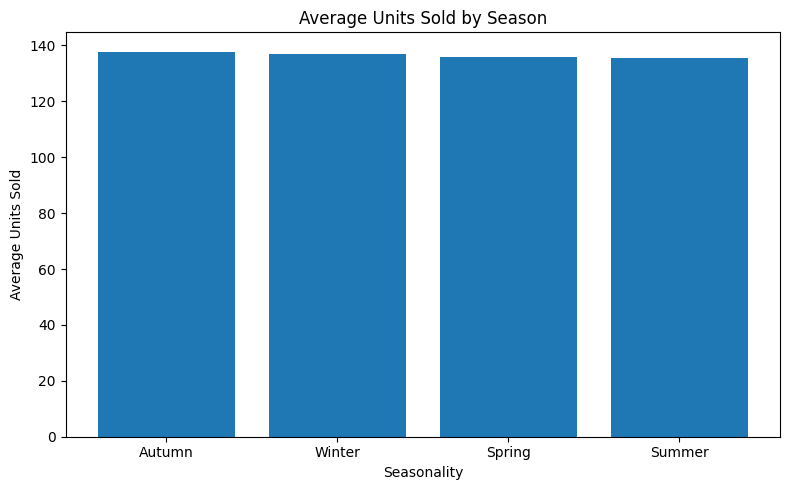

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(
    seasonality_analysis.index,
    seasonality_analysis["avg_units_sold"]
)

plt.title("Average Units Sold by Season")
plt.xlabel("Seasonality")
plt.ylabel("Average Units Sold")

plt.tight_layout()
plt.show()

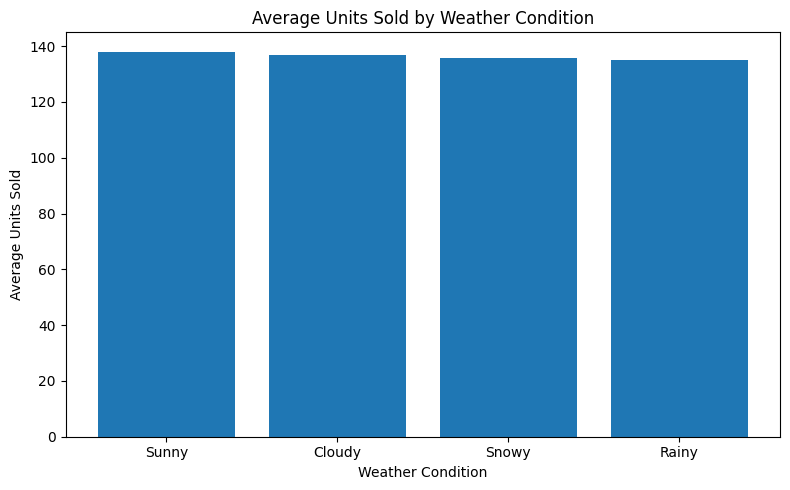

In [37]:
plt.figure(figsize=(8, 5))

plt.bar(
    weather_analysis.index,
    weather_analysis["avg_units_sold"]
)

plt.title("Average Units Sold by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Units Sold")

plt.tight_layout()
plt.show()

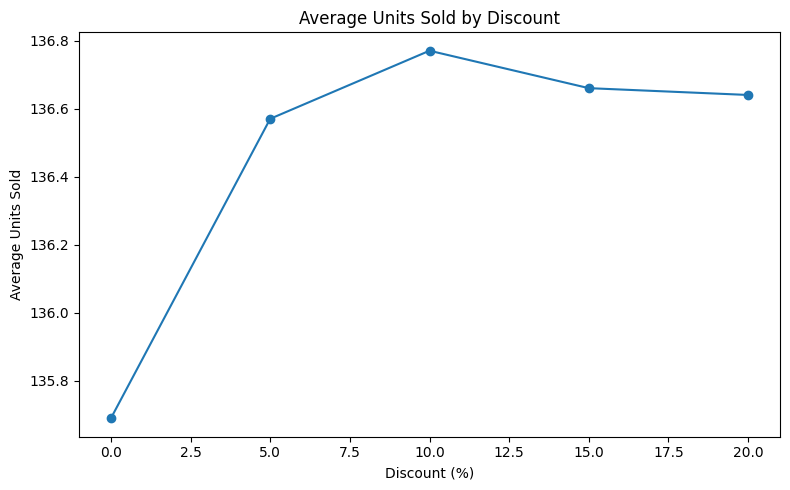

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    discount_analysis.index,
    discount_analysis["avg_units_sold"],
    marker="o"
)

plt.title("Average Units Sold by Discount")
plt.xlabel("Discount (%)")
plt.ylabel("Average Units Sold")

plt.tight_layout()
plt.show()

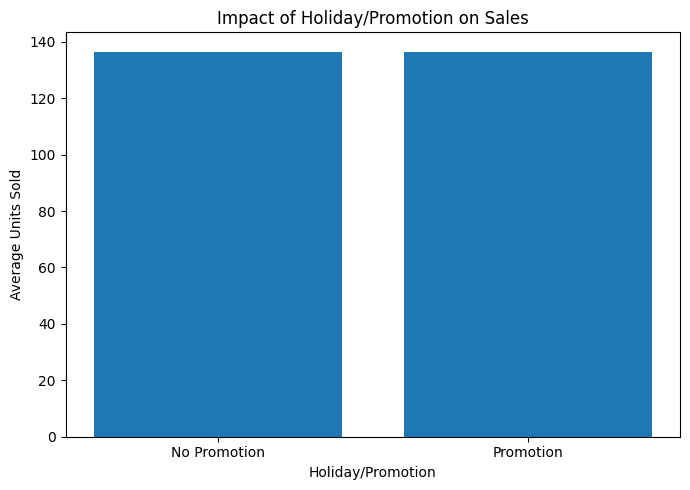

In [39]:
promotion_labels = ["No Promotion", "Promotion"]

plt.figure(figsize=(7, 5))

plt.bar(
    promotion_labels,
    promotion_analysis["avg_units_sold"]
)

plt.title("Impact of Holiday/Promotion on Sales")
plt.xlabel("Holiday/Promotion")
plt.ylabel("Average Units Sold")

plt.tight_layout()
plt.show()

In [40]:
# Final KPI Summary

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Observations",
        "Total Units Sold",
        "Total Units Ordered",
        "Average Inventory",
        "Average Demand Forecast",
        "Forecast MAE",
        "Forecast RMSE",
        "Forecast MAPE",
        "Overstock %",
        "Balanced Inventory %"
    ],
    "Value": [
        len(df),
        df["Units Sold"].sum(),
        df["Units Ordered"].sum(),
        round(df["Inventory Level"].mean(), 2),
        round(df["Demand Forecast"].mean(), 2),
        round(mae, 2),
        round(rmse, 2),
        round(mape, 2),
        round(
            100 * (
                df["Inventory Level"] > 1.5 * df["Demand Forecast"]
            ).mean(),
            2
        ),
        round(
            100 * (
                (df["Inventory Level"] >= 0.75 * df["Demand Forecast"]) &
                (df["Inventory Level"] <= 1.25 * df["Demand Forecast"])
            ).mean(),
            2
        )
    ]
})

kpi_summary

,Metric,Value
0,Total Observations,73100.00
1,Total Units Sold,9975582.00
2,Total Units Ordered,8041327.00
3,Average Inventory,274.47
4,Average Demand Forecast,141.53
5,Forecast MAE,8.30
6,Forecast RMSE,10.00
7,Forecast MAPE,23.29
8,Overstock %,64.41
9,Balanced Inventory %,22.46


In [41]:
# Final KPI Summary

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Observations",
        "Total Units Sold",
        "Total Units Ordered",
        "Average Inventory",
        "Average Demand Forecast",
        "Forecast MAE",
        "Forecast RMSE",
        "Forecast MAPE",
        "Overstock %",
        "Balanced Inventory %"
    ],
    "Value": [
        len(df),
        df["Units Sold"].sum(),
        df["Units Ordered"].sum(),
        round(df["Inventory Level"].mean(), 2),
        round(df["Demand Forecast"].mean(), 2),
        round(mae, 2),
        round(rmse, 2),
        round(mape, 2),
        round(
            100 * (
                df["Inventory Level"] > 1.5 * df["Demand Forecast"]
            ).mean(),
            2
        ),
        round(
            100 * (
                (df["Inventory Level"] >= 0.75 * df["Demand Forecast"]) &
                (df["Inventory Level"] <= 1.25 * df["Demand Forecast"])
            ).mean(),
            2
        )
    ]
})

kpi_summary

,Metric,Value
0,Total Observations,73100.00
1,Total Units Sold,9975582.00
2,Total Units Ordered,8041327.00
3,Average Inventory,274.47
4,Average Demand Forecast,141.53
5,Forecast MAE,8.30
6,Forecast RMSE,10.00
7,Forecast MAPE,23.29
8,Overstock %,64.41
9,Balanced Inventory %,22.46


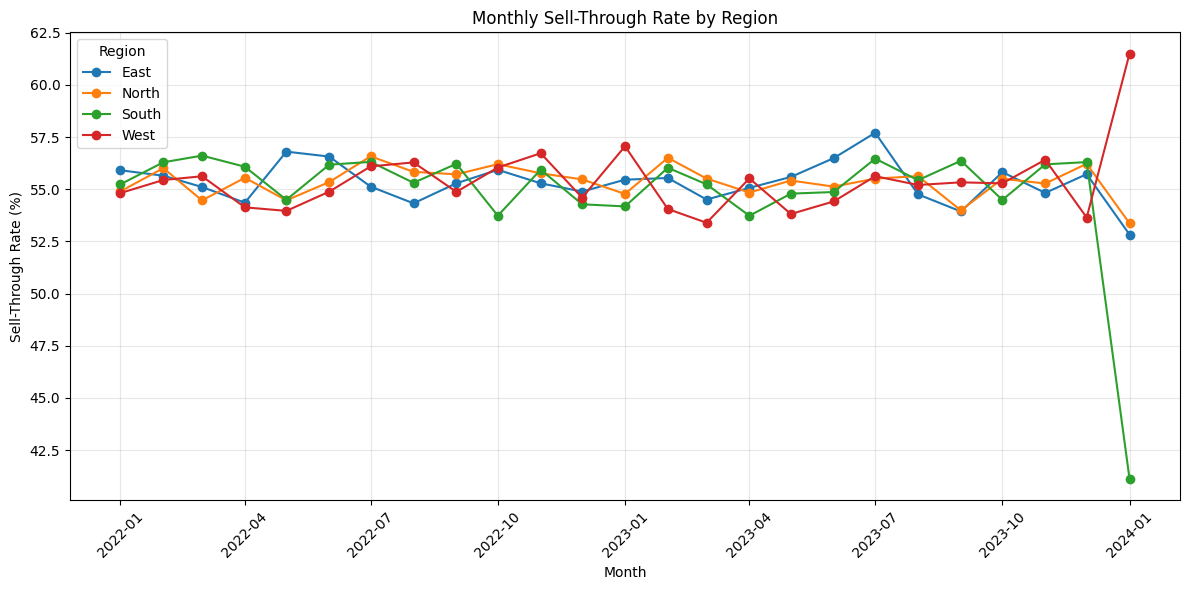

In [43]:
monthly_region = (
    df.groupby([df["Date"].dt.to_period("M"), "Region"])
      .agg(
          units_sold=("Units Sold", "sum"),
          units_ordered=("Units Ordered", "sum")
      )
      .reset_index()
)

monthly_region["Month"] = monthly_region["Date"].dt.to_timestamp()

monthly_region["sell_through_rate"] = (
    monthly_region["units_sold"] /
    (monthly_region["units_sold"] + monthly_region["units_ordered"])
) * 100

plt.figure(figsize=(12, 6))

for region in monthly_region["Region"].unique():
    temp = monthly_region[monthly_region["Region"] == region]
    plt.plot(
        temp["Month"],
        temp["sell_through_rate"],
        marker="o",
        label=region
    )

plt.title("Monthly Sell-Through Rate by Region")
plt.xlabel("Month")
plt.ylabel("Sell-Through Rate (%)")
plt.legend(title="Region")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

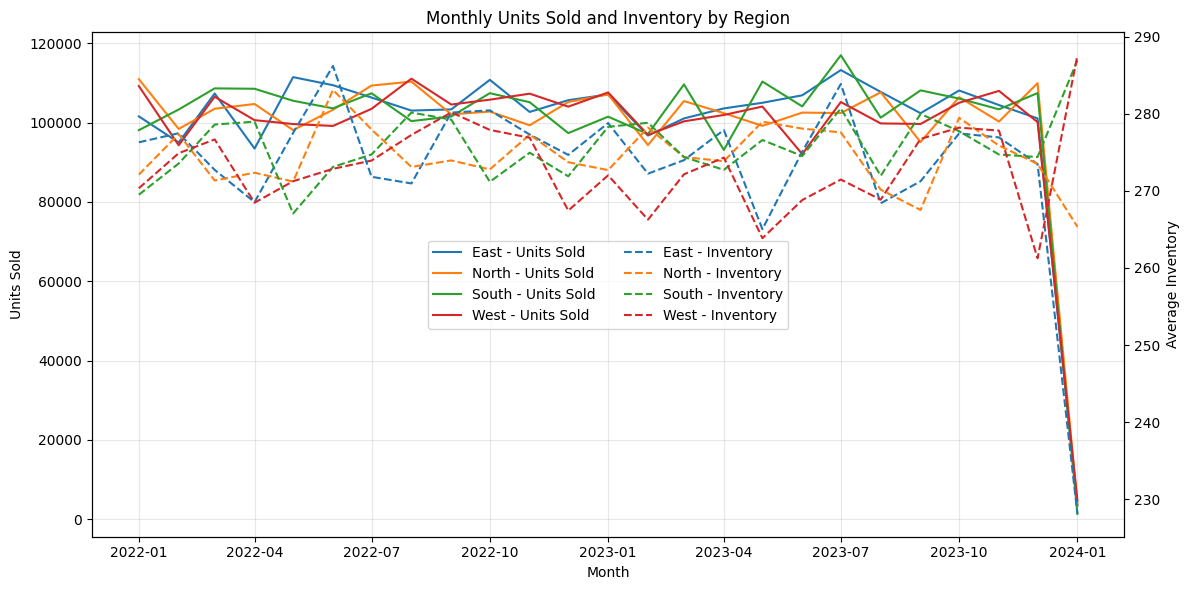

In [44]:
monthly_region = (
    df.groupby([df["Date"].dt.to_period("M"), "Region"])
      .agg(
          units_sold=("Units Sold", "sum"),
          avg_inventory=("Inventory Level", "mean")
      )
      .reset_index()
)

monthly_region["Month"] = monthly_region["Date"].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(12, 6))

for region in monthly_region["Region"].unique():
    temp = monthly_region[monthly_region["Region"] == region]
    ax1.plot(
        temp["Month"],
        temp["units_sold"],
        label=f"{region} - Units Sold"
    )

ax1.set_xlabel("Month")
ax1.set_ylabel("Units Sold")
ax1.set_title("Monthly Units Sold and Inventory by Region")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

for region in monthly_region["Region"].unique():
    temp = monthly_region[monthly_region["Region"] == region]
    ax2.plot(
        temp["Month"],
        temp["avg_inventory"],
        linestyle="--",
        label=f"{region} - Inventory"
    )

ax2.set_ylabel("Average Inventory")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="center",
    bbox_to_anchor=(0.5, 0.5),
    ncol=2
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

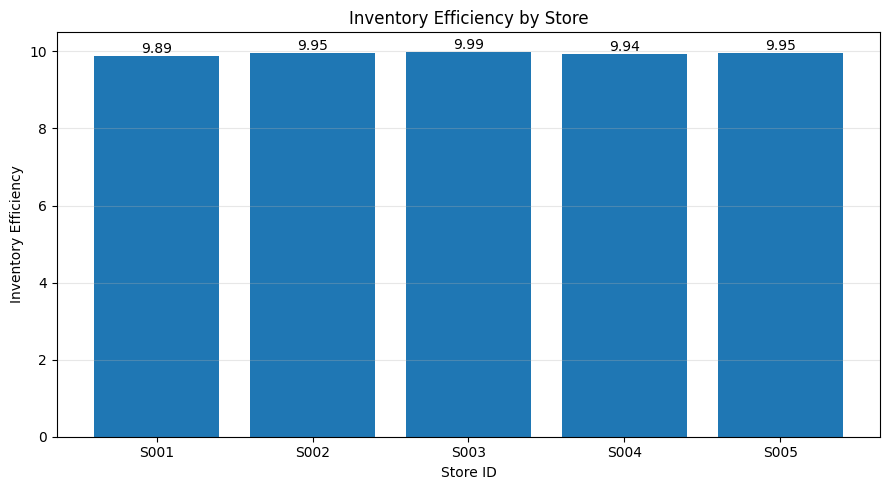

In [45]:
store_efficiency = (
    df.groupby("Store ID")
      .agg(
          total_units_sold=("Units Sold", "sum"),
          avg_inventory=("Inventory Level", "mean"),
          avg_demand_forecast=("Demand Forecast", "mean")
      )
      .reset_index()
)

store_efficiency["inventory_efficiency"] = (
    store_efficiency["total_units_sold"] /
    (store_efficiency["avg_inventory"] * len(df["Date"].unique()))
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    store_efficiency["Store ID"],
    store_efficiency["inventory_efficiency"]
)

plt.title("Inventory Efficiency by Store")
plt.xlabel("Store ID")
plt.ylabel("Inventory Efficiency")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

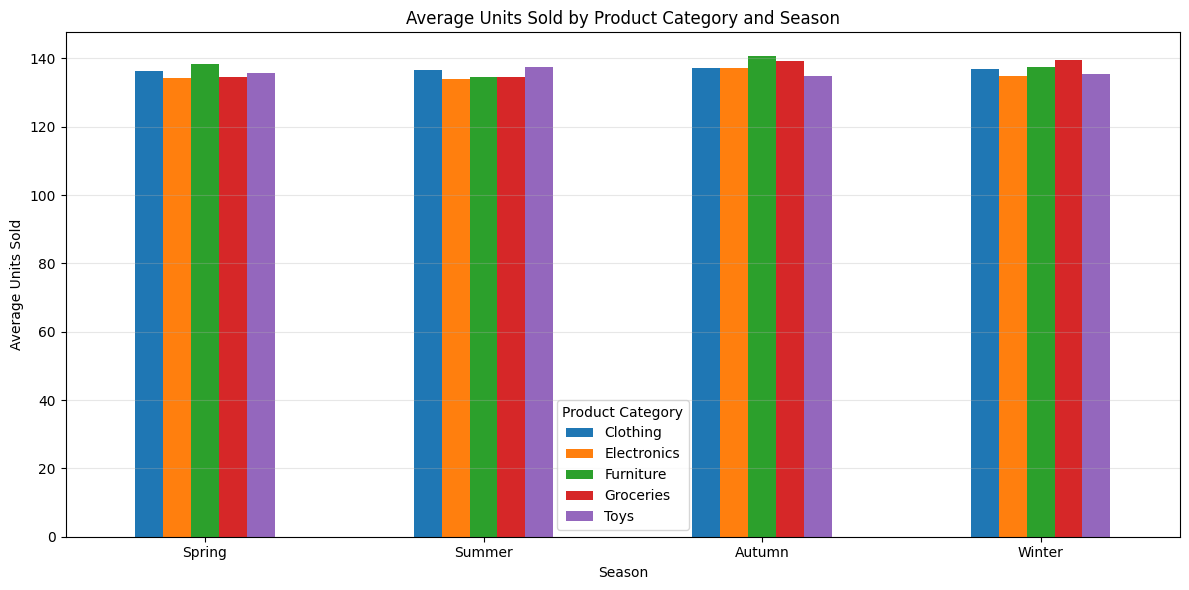

In [46]:
category_season = (
    df.groupby(["Seasonality", "Category"])
      ["Units Sold"]
      .mean()
      .reset_index()
)

pivot_season = category_season.pivot(
    index="Seasonality",
    columns="Category",
    values="Units Sold"
)

season_order = ["Spring", "Summer", "Autumn", "Winter"]
pivot_season = pivot_season.reindex(season_order)

pivot_season.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Units Sold by Product Category and Season")
plt.xlabel("Season")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)
plt.legend(title="Product Category")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

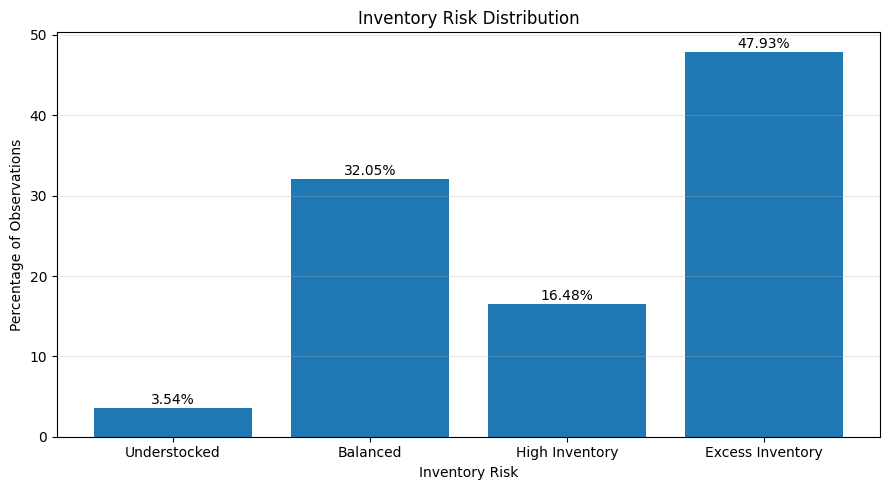

In [47]:
risk_counts = (
    df["inventory_risk"]
      .value_counts()
      .reindex([
          "Understocked",
          "Balanced",
          "High Inventory",
          "Excess Inventory"
    ])
)

risk_pct = (risk_counts / len(df)) * 100

plt.figure(figsize=(9, 5))

bars = plt.bar(
    risk_pct.index,
    risk_pct.values
)

plt.title("Inventory Risk Distribution")
plt.xlabel("Inventory Risk")
plt.ylabel("Percentage of Observations")

for bar, value in zip(bars, risk_pct.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

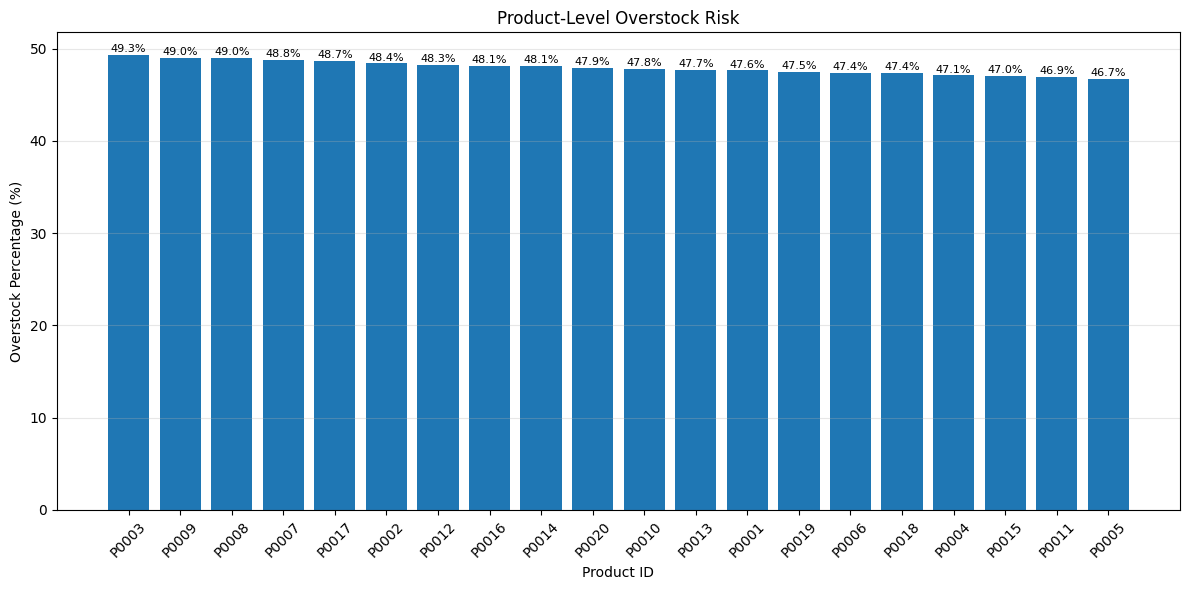

In [48]:
product_overstock = (
    df.groupby("Product ID")
      .agg(
          observations=("Product ID", "size"),
          overstock_observations=("inventory_risk",
                                  lambda x: (x == "Excess Inventory").sum())
      )
      .reset_index()
)

product_overstock["overstock_pct"] = (
    product_overstock["overstock_observations"] /
    product_overstock["observations"]
) * 100

product_overstock = product_overstock.sort_values(
    "overstock_pct",
    ascending=False
)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    product_overstock["Product ID"],
    product_overstock["overstock_pct"]
)

plt.title("Product-Level Overstock Risk")
plt.xlabel("Product ID")
plt.ylabel("Overstock Percentage (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, product_overstock["overstock_pct"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.3,
        f"{value:.1f}%",
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

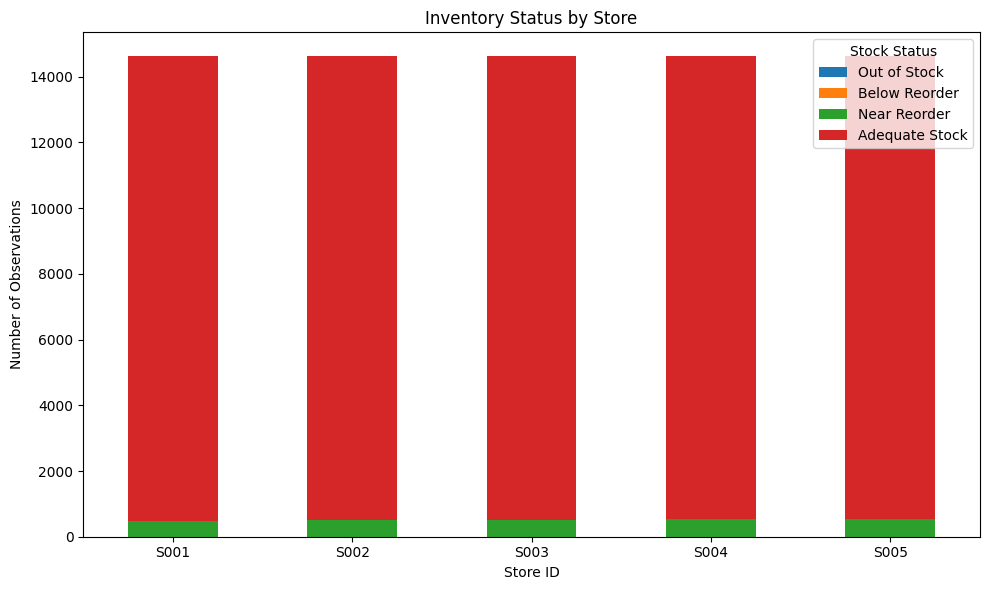

In [49]:
def inventory_status(row):
    if row["Inventory Level"] == 0:
        return "Out of Stock"
    elif row["Inventory Level"] < row["Demand Forecast"] * 0.75:
        return "Below Reorder"
    elif row["Inventory Level"] < row["Demand Forecast"]:
        return "Near Reorder"
    else:
        return "Adequate Stock"

df["inventory_status"] = df.apply(inventory_status, axis=1)

store_status = (
    df.groupby(["Store ID", "inventory_status"])
      .size()
      .unstack(fill_value=0)
)

status_order = [
    "Out of Stock",
    "Below Reorder",
    "Near Reorder",
    "Adequate Stock"
]

store_status = store_status.reindex(
    columns=status_order,
    fill_value=0
)

store_status.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Inventory Status by Store")
plt.xlabel("Store ID")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)
plt.legend(title="Stock Status")
plt.tight_layout()
plt.show()